## 1. Reading Modules


In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
from keras.optimizers import Adam, SGD, RMSprop
import tensorflow as tf
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np
from scipy import ndimage, misc
import skimage
from keras.applications.inception_v3 import InceptionV3, preprocess_input
from keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.layers import Dense, Dropout



In [2]:
import os
import hashlib
from collections import defaultdict
import shutil

def get_image_hash(image_path):
    """Generate a hash for an image file."""
    hash_func = hashlib.md5()
    with open(image_path, 'rb') as f:
        while chunk := f.read(8192):
            hash_func.update(chunk)
    return hash_func.hexdigest()

def find_and_move_duplicate_images(main_folder, subfolders, target_folder):
    """Find and move duplicate images to the target folder."""
    hash_dict = defaultdict(list)
    
    for folder in subfolders:
        folder_path = os.path.join(main_folder, folder)
        if os.path.isdir(folder_path):
            for root, _, files in os.walk(folder_path):
                for file in files:
                    file_path = os.path.join(root, file)
                    file_hash = get_image_hash(file_path)
                    hash_dict[file_hash].append(file_path)
    
    duplicates = {hash_val: paths for hash_val, paths in hash_dict.items() if len(paths) > 1}
    
    if not os.path.exists(target_folder):
        os.makedirs(target_folder)

    if duplicates:
        print("Duplicate images found and moved to target folder:")
        for hash_val, paths in duplicates.items():
            # Keep the first occurrence and move the rest
            for duplicate_path in paths[1:]:
                target_path = os.path.join(target_folder, os.path.basename(duplicate_path))
                shutil.move(duplicate_path, target_path)
                print(f"Moved: {duplicate_path} -> {target_path}")
    else:
        print("No duplicate images found.")

# Define the main folder, subfolders, and target folder
main_folder = 'images'
subfolders = ['Bengal', 'Bombay', 'Dilute Tortoiseshell','Maine Coon', 'Persian', 'Ragdoll', 'Siamese', 'Tabby', 'Tortoiseshell', 'Tuxedo']
target_folder = 'duplicate_images'

# Find and move duplicate images
find_and_move_duplicate_images(main_folder, subfolders, target_folder)


No duplicate images found.


In [3]:
from livelossplot import PlotLossesKeras

In [4]:
filelist  = []

for dirname, _, filenames in os.walk('./images'):
    for filename in filenames:
        filelist.append (os.path.join(dirname, filename))
        


In [5]:
len(filelist)

125402

In [6]:
# filelist

### Taking only those class with 500+ images here.

In [7]:
labels_needed = ['Bengal', 'Bombay', 'Dilute Tortoiseshell','Himalayan', 'Persian', 'Ragdoll', 'Siamese', 'Tabby', 'Tortoiseshell', 'Tuxedo']

In [8]:
# Filepaths   = []
# labels = []

# label_counts = {label: 0 for label in labels_needed}

# for image_file in filelist:
#     label = image_file.split(os.path.sep)[-2]
#     if label in labels_needed and label_counts[label] < 1500:
#         Filepaths.append(image_file)
#         labels.append(label)
#         label_counts[label] += 1

Filepaths   = []
labels = []

for image_file in filelist:
    label = image_file.split(os.path.sep)[-2]
    if label in labels_needed:

        Filepaths.append(image_file)
        labels.append(label)


In [9]:
set(labels)

{'Bengal',
 'Bombay',
 'Dilute Tortoiseshell',
 'Himalayan',
 'Persian',
 'Ragdoll',
 'Siamese',
 'Tabby',
 'Tortoiseshell',
 'Tuxedo'}

In [10]:
len(Filepaths), len(labels)

(27798, 27798)

### Creating a dataframe with file paths and the labels for them

In [11]:
df = pd.DataFrame( list( zip (Filepaths, labels) ), columns = ['Filepath', 'Labels'] )
df

,Filepath,Labels
0,./images\Bengal\15751520_9790.jpg,Bengal
1,./images\Bengal\16177789_9728.jpg,Bengal
2,./images\Bengal\16324794_9688.jpg,Bengal
3,./images\Bengal\16988413_9537.jpg,Bengal
4,./images\Bengal\16993696_9535.jpg,Bengal
...,...,...
27793,./images\Tuxedo\46803893_19.jpg,Tuxedo
27794,./images\Tuxedo\46803894_20.jpg,Tuxedo
27795,./images\Tuxedo\46804405_13.jpg,Tuxedo
27796,./images\Tuxedo\46806582_5.jpg,Tuxedo


In [12]:
from sklearn.utils import shuffle
df = (df.sample(frac = 1).reset_index()).drop(columns = 'index')
df


,Filepath,Labels
0,./images\Tuxedo\43742053_7368.jpg,Tuxedo
1,./images\Persian\44257026_901.jpg,Persian
2,./images\Ragdoll\28992767_5072.jpg,Ragdoll
3,./images\Ragdoll\37386944_2618.jpg,Ragdoll
4,./images\Ragdoll\26880222_5718.jpg,Ragdoll
...,...,...
27793,./images\Bengal\30852100_5485.jpg,Bengal
27794,./images\Tuxedo\45603868_3069.jpg,Tuxedo
27795,./images\Tuxedo\42759197_9438.jpg,Tuxedo
27796,./images\Bombay\42146333_2054.jpg,Bombay


### Displaying first 12 pictures

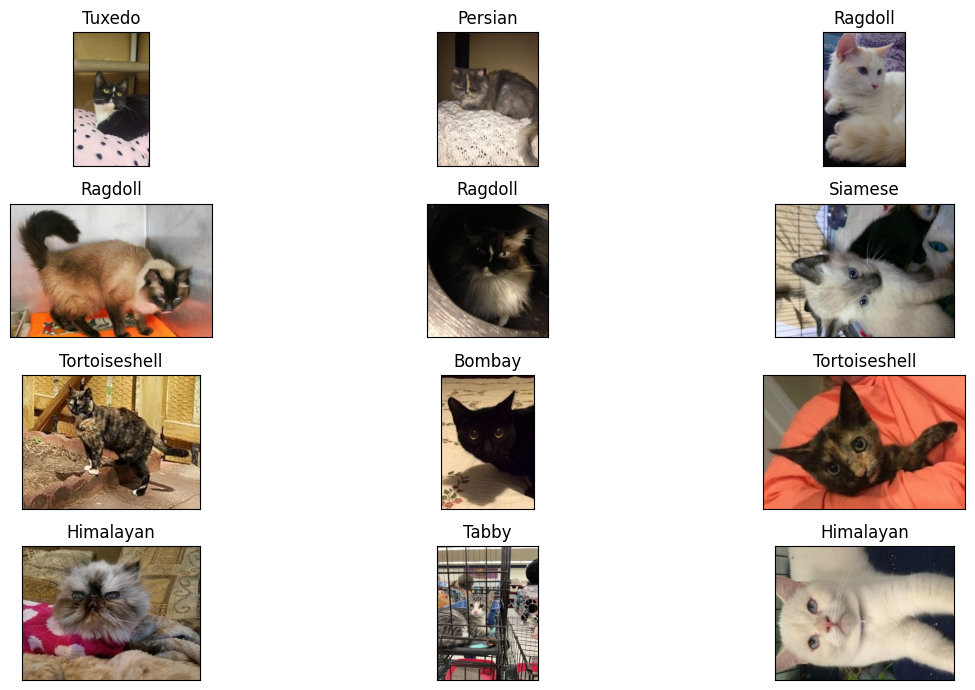

In [13]:
f,a = plt.subplots(nrows=4, ncols=3,figsize=(13, 7),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(a.flat):
    ax.imshow(plt.imread(df.Filepath[i]))
    ax.set_title(df.Labels[i])
    
plt.tight_layout()
plt.show()

C:\Users\k3n\AppData\Local\Temp\ipykernel_23168\1936985648.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  ax=pd.value_counts(df['Labels'],ascending=True).plot(kind='barh',


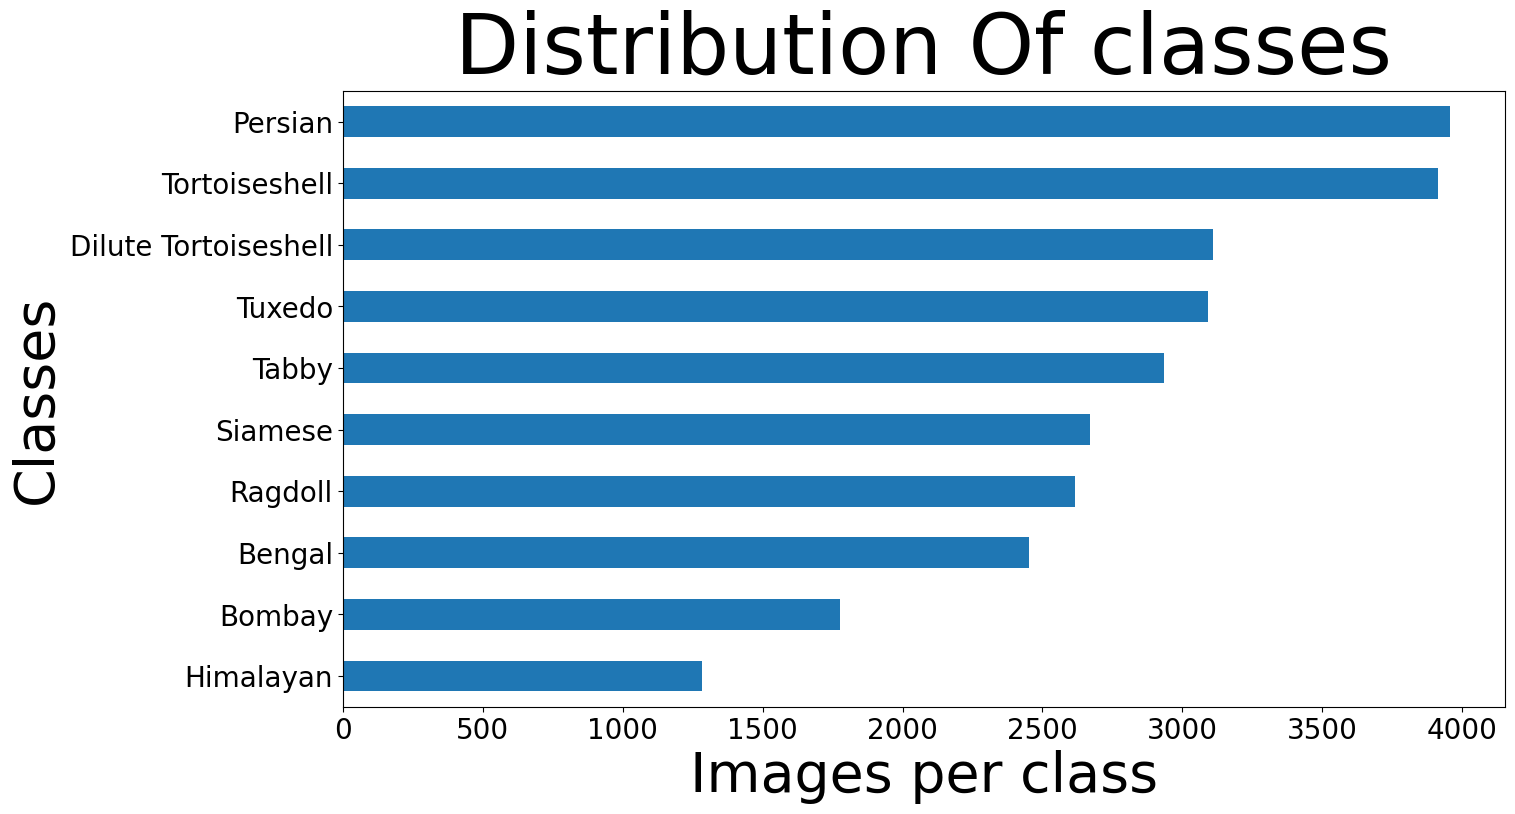

In [14]:
ax=pd.value_counts(df['Labels'],ascending=True).plot(kind='barh',
                                                       fontsize="20",
                                                       title="Distribution Of classes",
                                                       figsize=(15,8))
ax.set(xlabel="Images per class", ylabel="Classes")
ax.xaxis.label.set_size(40)
ax.yaxis.label.set_size(40)
ax.title.set_size(60)
plt.show()

### Checking for class imbalance

In [15]:
df.Labels.value_counts()

Labels
Persian                 3955
Tortoiseshell           3912
Dilute Tortoiseshell    3110
Tuxedo                  3090
Tabby                   2933
Siamese                 2670
Ragdoll                 2617
Bengal                  2451
Bombay                  1778
Himalayan               1282
Name: count, dtype: int64

### Splitting the data And Creating data generator

In [16]:
train_ratio = .70
validation_ratio = 0.10
test_ratio = 0.20

train, test = train_test_split(df, test_size = test_ratio )
val, test = train_test_split(test, test_size=test_ratio/(test_ratio + validation_ratio))

In [17]:
img_datagen = ImageDataGenerator(
    rescale=1./255, 
    rotation_range=40, 
    width_shift_range=0.3,
    height_shift_range=0.3, 
    horizontal_flip=True,
    shear_range=0.2, 
    zoom_range=0.2,
    fill_mode='nearest',
    brightness_range=[0.8, 1.2],
    channel_shift_range=0.1,
    preprocessing_function=lambda x: x + np.random.normal(loc=0.0, scale=0.01, size=x.shape)
)

x_train = img_datagen.flow_from_dataframe(dataframe=train, x_col='Filepath', y_col='Labels', target_size=(299, 299), shuffle=False, batch_size=16, seed=10)
x_val = img_datagen.flow_from_dataframe(dataframe=val, x_col='Filepath', y_col='Labels', target_size=(299, 299), shuffle=False, batch_size=16, seed=10)
x_test = img_datagen.flow_from_dataframe(dataframe=test, x_col='Filepath', y_col='Labels', target_size=(299, 299), shuffle=False, batch_size=16, seed=10)


Found 22238 validated image filenames belonging to 10 classes.
Found 1853 validated image filenames belonging to 10 classes.
Found 3707 validated image filenames belonging to 10 classes.


In [18]:
x_train

### Modelling

In [19]:

i_model = InceptionV3(weights= 'imagenet', include_top=False, input_shape=(299, 299, 3))

In [20]:
for layer in i_model.layers:
    layer.trainable = False
    
# i_model.summary()

In [21]:
#for layer in i_model.layers[-20:]:
 #   layer.trainable = True
#ito yung nag 32 val_loss

In [22]:
from keras.regularizers import l2
from tensorflow.keras.layers import BatchNormalization


model = Sequential()
model.add(i_model)
model.add(GlobalAveragePooling2D())
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.01)))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))
model.build((None, 299, 299, 3))


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_95          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,074,730 (84.21 MB)

 Trainable params: 271,562 (1.04 MB)

 Non-trainable params: 21,803,168 (83.17 MB)

In [23]:
model.compile(optimizer = Adam(0.001),
             loss="categorical_crossentropy",
             metrics=["accuracy"])

In [24]:
from keras.callbacks import EarlyStopping

# Define early stopping criteria
early_stopping = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

In [25]:
from keras.callbacks import LearningRateScheduler

# Define a learning rate schedule function with a lower initial learning rate
def lr_schedule(epoch):
    initial_lr = 0.001  # Lower initial learning rate
    decay_rate = 0.7    # Rate of decay
    decay_steps = 3     # Number of epochs after which to decay the learning rate
    if epoch >= decay_steps:
        return initial_lr * (decay_rate ** ((epoch - decay_steps) // decay_steps))
    else:
        return initial_lr


In [26]:
from sklearn.utils import class_weight

# Calculate class weights
class_weights = class_weight.compute_class_weight('balanced',
                                                  classes=np.unique(train['Labels']),
                                                  y=train['Labels'])
class_weights = dict(enumerate(class_weights))

In [27]:
history = model.fit(x_train, validation_data=x_val,
                    steps_per_epoch=len(x_train) // 16,
                    validation_steps=len(x_val) // 16,
                    epochs=16,
                    class_weight=class_weights,
                    callbacks=[LearningRateScheduler(lr_schedule), early_stopping],
                    verbose=2)

Epoch 1/16


C:\Users\k3n\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


86/86 - 79s - 917ms/step - accuracy: 0.2253 - loss: 5.5206 - val_accuracy: 0.4554 - val_loss: 4.2999 - learning_rate: 0.0010
Epoch 2/16
86/86 - 63s - 737ms/step - accuracy: 0.3321 - loss: 4.5005 - val_accuracy: 0.4643 - val_loss: 3.8775 - learning_rate: 0.0010
Epoch 3/16
86/86 - 63s - 731ms/step - accuracy: 0.3990 - loss: 3.8400 - val_accuracy: 0.5804 - val_loss: 3.1604 - learning_rate: 0.0010
Epoch 4/16
86/86 - 64s - 739ms/step - accuracy: 0.4062 - loss: 3.5038 - val_accuracy: 0.4821 - val_loss: 3.0632 - learning_rate: 0.0010
Epoch 5/16
86/86 - 63s - 733ms/step - accuracy: 0.4288 - loss: 3.1803 - val_accuracy: 0.5446 - val_loss: 2.7226 - learning_rate: 0.0010
Epoch 6/16
86/86 - 61s - 710ms/step - accuracy: 0.4804 - loss: 2.9038 - val_accuracy: 0.5893 - val_loss: 2.5858 - learning_rate: 0.0010
Epoch 7/16
86/86 - 62s - 721ms/step - accuracy: 0.4804 - loss: 2.6794 - val_accuracy: 0.6518 - val_loss: 2.1799 - learning_rate: 7.0000e-04
Epoch 8/16
86/86 - 63s - 733ms/step - accuracy: 0.5312 

KeyboardInterrupt: 

### Predicting on test data

In [ ]:
predictions = model.predict(x_test)


232/232 ━━━━━━━━━━━━━━━━━━━━ 168s 713ms/step


In [ ]:
print("ROC- AUC score is", roc_auc_score( test.Labels, predictions, multi_class='ovr'))

ROC- AUC score is 0.9485433377178412


In [ ]:
predictions = np.argmax(predictions, axis=1)
predictions

array([9, 8, 3, ..., 0, 9, 9], dtype=int64)

In [ ]:
labels = x_train.class_indices
labels

{'Bengal': 0,
 'Bombay': 1,
 'Dilute Tortoiseshell': 2,
 'Himalayan': 3,
 'Persian': 4,
 'Ragdoll': 5,
 'Siamese': 6,
 'Tabby': 7,
 'Tortoiseshell': 8,
 'Tuxedo': 9}

In [ ]:
test["Labels"].replace({
    'Bengal': 0,
    'Bombay': 1,
    'Dilute Tortoiseshell': 2,
    'Himalayan': 3,
    'Persian': 4,
    'Ragdoll': 5,
    'Siamese': 6,
    'Tabby': 7,
    'Tortoiseshell': 8,
    'Tuxedo': 9
}, inplace = True)


# Evaluating the test data

## Test Accuracy

In [ ]:
test_accuracy = model.evaluate(x_test)[1] * 100
print('Test accuracy is : ',test_accuracy, '%' )

232/232 ━━━━━━━━━━━━━━━━━━━━ 159s 683ms/step - accuracy: 0.6884 - loss: 1.2429
Test accuracy is :  68.16833019256592 %


## Confusion Matrix

In [ ]:
cf = confusion_matrix(test.Labels , predictions)


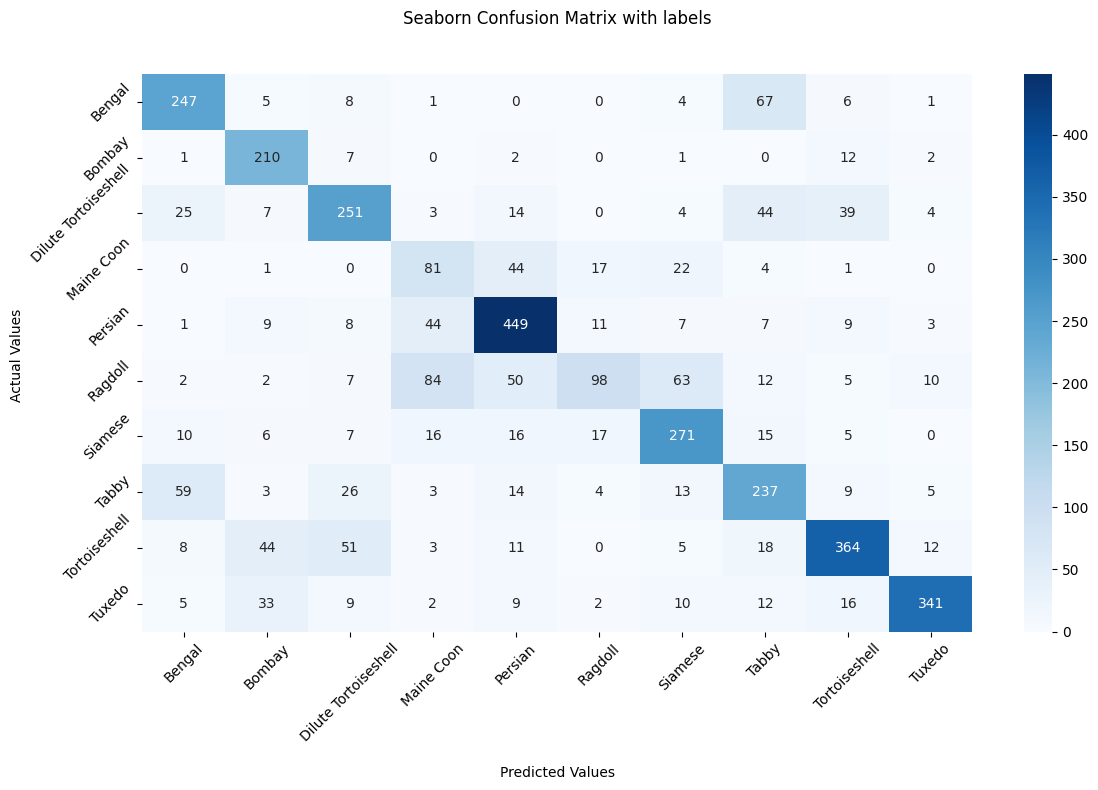

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming test.Labels and predictions are defined
cf = confusion_matrix(test.Labels, predictions)

# Set the figure size
plt.figure(figsize=(12, 8))

# Create the heatmap
ax = sns.heatmap(cf, annot=True, cmap='Blues', fmt='g')

# Add titles and labels
ax.set_title('Seaborn Confusion Matrix with labels\n\n')
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ')


# Set tick labels
ax.xaxis.set_ticklabels(['Bengal', 'Bombay', 'Dilute Tortoiseshell','Maine Coon', 'Persian', 'Ragdoll', 'Siamese', 'Tabby', 'Tortoiseshell', 'Tuxedo'], rotation=45)
ax.yaxis.set_ticklabels(['Bengal', 'Bombay', 'Dilute Tortoiseshell','Maine Coon', 'Persian', 'Ragdoll', 'Siamese', 'Tabby', 'Tortoiseshell', 'Tuxedo'], rotation=45)

# Display the visualization
plt.tight_layout()
plt.show()

## F1 Score

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
print('F1 score is',f1_score(test.Labels, predictions, average = 'weighted'))


F1 score is 0.6835777204749044


## ROC - AUC Score

In [ ]:
len(x_train)

1390

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Predicted class: Bengal, Confidence: 0.8929169178009033


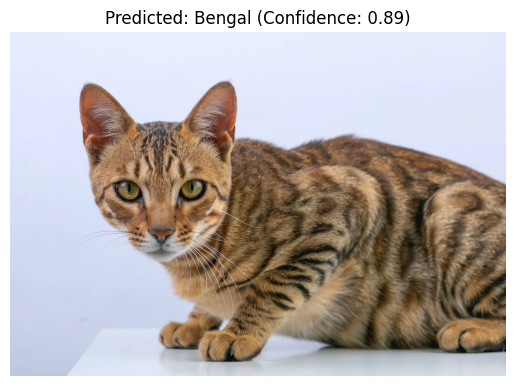

Bengal: 89.29%
Bombay: 0.09%
Dilute Tortoiseshell: 1.86%
Main Coon: 0.30%
Persian: 0.10%
Ragdoll: 0.12%
Siamese: 0.39%
Tabby: 7.34%
Tortoiseshell: 0.46%
Tuxedo: 0.04%


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from keras.applications.inception_v3 import InceptionV3, preprocess_input

# Define the class names
class_names = [
    'Bengal', 
    'Bombay', 
    'Dilute Tortoiseshell', 
    'Main Coon', 
    'Persian', 
    'Ragdoll', 
    'Siamese', 
    'Tabby', 
    'Tortoiseshell', 
    'Tuxedo'
]

# Load and preprocess the image
def load_and_preprocess_image(img_path, target_size=(299, 299)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = preprocess_input(img_array)  # Preprocess for InceptionV3
    return img_array

# Predict the class of the image and get all class probabilities
def predict_image_class(model, img_path, class_names):
    img_array = load_and_preprocess_image(img_path)
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions, axis=1)
    confidence = np.max(predictions)
    return class_names[predicted_class[0]], confidence, predictions

# Assuming your model is loaded as 'model'
img_path = 'bengal_tester.jpg'  # Replace with the path to your image
predicted_class, confidence, predictions = predict_image_class(model, img_path, class_names)

print(f"Predicted class: {predicted_class}, Confidence: {confidence}")

# Display the image
img = image.load_img(img_path)
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} (Confidence: {confidence:.2f})")
plt.axis('off')
plt.show()

# Display the probabilities for all classes
for class_name, prob in zip(class_names, predictions[0]):
    print(f"{class_name}: {prob * 100:.2f}%")
